In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
epochs = 8
learning_rate = 0.001
batch_size = 64
display_step = 32 # sau mỗi 32 batch thì display 1 lần

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ex11', 'data')
os.makedirs(os.path.join(base_dir, 'Ex11', 'model'), exist_ok = True)
checkpoint_dir = os.path.join(os.path.join(base_dir, 'Ex11', 'model', 'basicnn.pth'))

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda'

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(data_dir, train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(data_dir, train = False, download = True, transform = transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 64)

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 64, kernel_size = 3)
        self.maxpool1 = nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3)
        self.maxpool2 = nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2)
        self.conv3 = nn.Conv2d(in_channels = 128, out_channels = 256, kernel_size = 3)
        self.maxpool3 = nn.AdaptiveMaxPool2d((1,1)) #đầu vào tuple
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 10)
    
    def forward(self, X):
        X = self.conv1(X)
        X = self.relu(X)
        X = self.maxpool1(X)
        X = self.conv2(X)
        X = self.relu(X)
        X = self.maxpool2(X)
        X = self.conv3(X)
        X = self.relu(X)
        X = self.maxpool3(X)
        X = self.flatten(X)
        X = self.fc1(X)
        X = self.dropout(X) # drop ngẫu nhiên đầu ra của fc1
        X = self.fc2(X)
        X = self.fc3(X)
        return X

In [8]:
# có thể sử dụng criterion trực tiếp của nn hoặc của nn.functional bài này sử dụng của F
net = Net()
optimizer = optim.Adam(net.parameters(), lr = 1e-3)
best_val_loss = 999
device = torch.device(device)
net.to(device)
for epoch in range(1, epochs + 1):
    net.train()
    for batch_id, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = net(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step() # step của optimizer cập nhật các trọng số của model nhưng không thêm vào đò thị tính toán

        if batch_id % display_step == 0:
            print(f'Epoch: {epoch}, [{batch_id * len(data)}/{len(train_loader.dataset)}, ({(100. * batch_id * len(data)/len(train_loader.dataset)):.1f}%)]\tLoss: {loss.item()}')
        
    # phải tách bạch train và test vì trong train dropout hoạt động khác khi test, khi test dùng hết 
    net.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = net(data) # batch * 10
            test_loss += F.cross_entropy(output, target, reduction = 'sum').item()
            pred = output.argmax(dim = 1) # = batch size
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss/=len(test_loader.dataset)
    test_acc = 100.*correct/len(test_loader.dataset)
    print(f"Epoch: {epoch}, avg test loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")

    if test_loss < best_val_loss:
        best_val_loss = test_loss
        torch.save(net.state_dict(), checkpoint_dir)
        print(f"***********    NEW MODEL SAVED    ***********")

Epoch: 1, [0/60000, (0.0%)]	Loss: 2.3228678703308105
Epoch: 1, [2048/60000, (3.4%)]	Loss: 0.5659922361373901
Epoch: 1, [4096/60000, (6.8%)]	Loss: 0.393775075674057
Epoch: 1, [6144/60000, (10.2%)]	Loss: 0.10331933200359344
Epoch: 1, [8192/60000, (13.7%)]	Loss: 0.5509814023971558
Epoch: 1, [10240/60000, (17.1%)]	Loss: 0.21938779950141907
Epoch: 1, [12288/60000, (20.5%)]	Loss: 0.047004878520965576
Epoch: 1, [14336/60000, (23.9%)]	Loss: 0.3403220772743225
Epoch: 1, [16384/60000, (27.3%)]	Loss: 0.24615544080734253
Epoch: 1, [18432/60000, (30.7%)]	Loss: 0.031835563480854034
Epoch: 1, [20480/60000, (34.1%)]	Loss: 0.0219064112752676
Epoch: 1, [22528/60000, (37.5%)]	Loss: 0.21076002717018127
Epoch: 1, [24576/60000, (41.0%)]	Loss: 0.26943260431289673
Epoch: 1, [26624/60000, (44.4%)]	Loss: 0.17903922498226166
Epoch: 1, [28672/60000, (47.8%)]	Loss: 0.236362487077713
Epoch: 1, [30720/60000, (51.2%)]	Loss: 0.07946670800447464
Epoch: 1, [32768/60000, (54.6%)]	Loss: 0.12822987139225006
Epoch: 1, [3481

In [9]:
# thử load model đã train
basic_cnn = Net()
#basic_cnn.load_state_dict(torch.load(checkpoint_dir))

In [12]:
basic_cnn.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-0.2656, -0.2659,  0.1043],
                        [ 0.0221, -0.2655, -0.3252],
                        [-0.2686, -0.2576, -0.2304]]],
              
              
                      [[[ 0.2159, -0.1315,  0.0600],
                        [-0.1653, -0.2675,  0.0019],
                        [-0.1374,  0.3228,  0.2469]]],
              
              
                      [[[-0.1073, -0.2658, -0.2969],
                        [ 0.0466, -0.1435,  0.1072],
                        [ 0.1453, -0.1638, -0.0215]]],
              
              
                      [[[ 0.0138, -0.2103, -0.1658],
                        [-0.2260,  0.0247, -0.0028],
                        [-0.1615, -0.0258,  0.1986]]],
              
              
                      [[[-0.0835,  0.0292, -0.1822],
                        [-0.1457, -0.2726, -0.2420],
                        [ 0.2950,  0.1682, -0.0989]]],
              
              
               

In [13]:
basic_cnn.load_state_dict(torch.load(checkpoint_dir))

<All keys matched successfully>

In [14]:
basic_cnn.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-0.1479, -0.0498,  0.1421],
                        [-0.2053,  0.2179,  0.0022],
                        [ 0.1427, -0.3273, -0.1840]]],
              
              
                      [[[ 0.0610,  0.2100,  0.1169],
                        [-0.1775, -0.1805, -0.1747],
                        [ 0.0655, -0.0748,  0.0795]]],
              
              
                      [[[-0.0316, -0.2227, -0.1805],
                        [-0.0668, -0.1829,  0.2100],
                        [-0.0635, -0.2070,  0.2325]]],
              
              
                      [[[-0.0172, -0.0501, -0.2853],
                        [ 0.0622, -0.2884,  0.2457],
                        [-0.0790,  0.0481, -0.0198]]],
              
              
                      [[[ 0.0405, -0.2599, -0.1067],
                        [-0.0566,  0.0572,  0.0757],
                        [ 0.0739,  0.0842,  0.0263]]],
              
              
               

In [22]:
# lấy 1 batch từ test
item = iter(test_loader)
data, target = next(item)

In [23]:
import random
test_id = random.choice(range(len(data)))

In [24]:
data = data[test_id]
target = target[test_id]
data.shape

torch.Size([1, 28, 28])

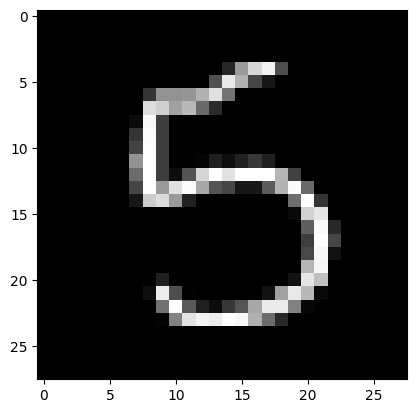

In [26]:
  plt.imshow(data[0].detach().cpu().numpy(),cmap='gray') 


In [37]:
basic_cnn.eval()
template = torch.randn((1,1,28,28))
data = data.detach().view_as(template)
with torch.no_grad():
    pred = basic_cnn(data)
    pred = pred.argmax(dim = 1).item()
    print(f'predicted number is: {pred}')

predicted number is: 5
